# Hands-On Week 13 — Classification & Clustering

**Topik utama:** Logistic Regression, K-Means Clustering, dan Evaluation Metrics  
**Tools:** Python, NumPy, Pandas, Matplotlib, Scikit-learn  
**Jenis kegiatan:** konsep + eksplorasi data + pemodelan + evaluasi + interpretasi output

---

## Capaian Pembelajaran

Setelah mengikuti hands-on ini, mahasiswa diharapkan mampu:

1. menjelaskan perbedaan **classification** dan **clustering**;
2. membangun model **logistic regression** untuk masalah klasifikasi biner;
3. mengevaluasi model klasifikasi menggunakan **confusion matrix**, **accuracy**, **precision**, **recall**, **F1-score**, dan **ROC-AUC**;
4. menjelaskan ide dasar **k-means clustering**;
5. memilih jumlah cluster menggunakan **elbow method** dan **silhouette score**;
6. mengevaluasi hasil clustering dan menginterpretasikan profil cluster;
7. memahami batasan evaluasi supervised dan unsupervised learning.

---

## Struktur Hands-On

Notebook ini terdiri atas beberapa bagian:

- **Bagian A** — Persiapan lingkungan kerja
- **Bagian B** — Konsep classification, clustering, dan evaluation metrics
- **Bagian C** — Logistic regression untuk classification
- **Bagian D** — Evaluation metrics untuk classification
- **Bagian E** — K-means clustering
- **Bagian F** — Evaluasi dan interpretasi clustering
- **Bagian G** — Latihan mandiri
- **Bagian H** — Ringkasan akhir

Notebook ini menggunakan dataset bawaan `scikit-learn`, sehingga dapat dijalankan tanpa mengunduh file eksternal.

# Bagian A — Persiapan Lingkungan Kerja

Pada bagian awal, kita memanggil pustaka yang dibutuhkan.  
Dataset yang digunakan berasal dari `scikit-learn` agar notebook mudah dijalankan di Google Colab maupun Jupyter Notebook.

In [ ]:
# ============================================================
# A.1 Import pustaka utama
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris, make_blobs
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    silhouette_score,
    adjusted_rand_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Agar hasil dapat direplikasi
RANDOM_STATE = 42

# Agar tampilan angka lebih rapi
pd.set_option("display.precision", 4)

print("Library berhasil dipanggil.")

Library berhasil dipanggil.


In [ ]:
# ============================================================
# A.2 Fungsi bantu sederhana
# ============================================================

def tampilkan_ukuran_data(X_train, X_test, y_train, y_test):
    print("Ukuran X_train:", X_train.shape)
    print("Ukuran X_test :", X_test.shape)
    print("Ukuran y_train:", y_train.shape)
    print("Ukuran y_test :", y_test.shape)


def evaluasi_klasifikasi(y_true, y_pred, y_prob=None, nama_model="Model"):
    # Fungsi untuk menampilkan beberapa metrik evaluasi klasifikasi biner.
    # y_prob bersifat opsional, digunakan untuk menghitung ROC-AUC.

    print(f"=== Evaluasi {nama_model} ===")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))

    if y_prob is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

# Bagian B — Konsep Dasar

## B.1 Classification

**Classification** adalah bagian dari supervised learning.  
Pada classification, target atau respons $Y$ berupa kategori/kelas.

Contoh:

| Kasus | Target |
|---|---|
| Diagnosis tumor | benign/malignant |
| Email | spam/non-spam |
| Nasabah | default/tidak default |
| Mahasiswa | lulus/tidak lulus |

Secara umum, data supervised learning memiliki pasangan:

$(X_i, Y_i), \quad i = 1,2,\ldots,n.$

Untuk classification, $Y_i$ adalah label kelas.

## B.2 Clustering

**Clustering** adalah bagian dari unsupervised learning.  
Pada clustering, data tidak memiliki label target.

Tujuannya adalah mengelompokkan observasi berdasarkan kemiripan fitur.

Contoh:

| Kasus | Tujuan |
|---|---|
| Segmentasi pelanggan | menemukan kelompok pelanggan serupa |
| Analisis wilayah | mengelompokkan daerah berdasarkan indikator sosial ekonomi |
| Biostatistika | mengelompokkan pasien berdasarkan karakteristik klinis |
| Keuangan | mengelompokkan saham berdasarkan profil risiko-return |

Dalam clustering, data hanya berbentuk:

$X_1, X_2,\ldots,X_n $

tanpa target $Y$.

## B.3 Classification vs Clustering

| Aspek | Classification | Clustering |
|---|---|---|
| Jenis learning | Supervised learning | Unsupervised learning |
| Ada target/label? | Ada | Tidak ada |
| Tujuan | Memprediksi kelas baru | Menemukan kelompok alami |
| Contoh metode | Logistic regression, decision tree, random forest | K-means, hierarchical clustering, DBSCAN |
| Evaluasi | Accuracy, precision, recall, F1-score, ROC-AUC | Inertia, silhouette score, interpretasi cluster |

Perbedaan paling penting:

> **Classification belajar dari label yang sudah tersedia, sedangkan clustering mencari struktur kelompok tanpa label.**

## B.4 Evaluation Metrics

Model tidak cukup hanya dibuat.  
Model harus dievaluasi.

Untuk classification, evaluasi biasanya membandingkan:

$\text{label aktual} \quad \text{vs} \quad \text{label prediksi}$

Untuk clustering, karena tidak ada label, evaluasi lebih sulit.  
Evaluasi biasanya menggunakan ukuran internal seperti:

- kekompakan cluster,
- keterpisahan antarcluster,
- interpretasi profil cluster.

---

## Check Point 1

Jawab secara singkat:

1. Apa perbedaan utama classification dan clustering?
2. Mengapa logistic regression termasuk supervised learning?
3. Mengapa k-means termasuk unsupervised learning?
4. Mengapa model perlu dievaluasi?
5. Apakah accuracy selalu cukup untuk menilai model klasifikasi?

# Bagian C — Logistic Regression untuk Classification

Pada bagian ini, kita menggunakan dataset **Breast Cancer Wisconsin** dari `scikit-learn`.

Dataset ini berisi karakteristik sel tumor dan target diagnosis:

- `malignant`
- `benign`

Tujuan kita adalah membangun model untuk memprediksi apakah tumor termasuk benign atau malignant berdasarkan fitur numerik.

In [ ]:
# ============================================================
# C.1 Load dataset Breast Cancer
# ============================================================

breast_cancer = load_breast_cancer()

X = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Encoding target dibuat lebih intuitif untuk evaluasi medis:
# 1 = malignant, 0 = benign
y = pd.Series(
    (breast_cancer.target == 0).astype(int),
    name="diagnosis_malignant"
)

class_names = {
    0: "benign",
    1: "malignant"
}

df = X.copy()
df["diagnosis_malignant"] = y
df["diagnosis_name"] = df["diagnosis_malignant"].map(class_names)

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis_malignant,diagnosis_name
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1,malignant
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1,malignant
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1,malignant
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1,malignant
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1,malignant


In [ ]:
# ============================================================
# C.2 Informasi dasar dataset
# ============================================================

print("Nama kelas target:")
print(class_names)

print("\nDistribusi kelas:")
print(df["diagnosis_name"].value_counts())

print("\nRingkasan statistik beberapa fitur:")
df.iloc[:, :8].describe()

Nama kelas target:
{0: 'benign', 1: 'malignant'}

Distribusi kelas:
diagnosis_name
benign       357
malignant    212
Name: count, dtype: int64

Ringkasan statistik beberapa fitur:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012


## C.1 Eksplorasi Awal

Sebelum membuat model, kita perlu memahami pola data.

Kita visualisasikan dua fitur:

- `mean radius`
- `mean texture`

Visualisasi dua dimensi tidak menangkap seluruh informasi, tetapi membantu memberi gambaran awal.

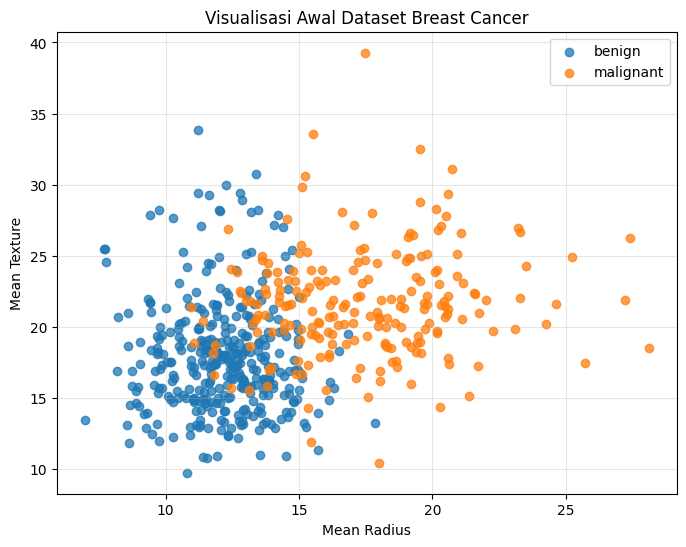

In [ ]:
# ============================================================
# C.3 Visualisasi dua fitur
# ============================================================

plt.figure(figsize=(8, 6))

for class_id, class_name in class_names.items():
    subset = df[df["diagnosis_malignant"] == class_id]
    plt.scatter(
        subset["mean radius"],
        subset["mean texture"],
        label=class_name,
        alpha=0.75
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Visualisasi Awal Dataset Breast Cancer")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## C.2 Train-Test Split

Kita membagi data menjadi:

- **training set** untuk melatih model;
- **testing set** untuk mengevaluasi model pada data baru.

Karena ini classification, pembagian data sebaiknya menggunakan `stratify=y` agar proporsi kelas pada training dan testing tetap seimbang.

In [ ]:
# ============================================================
# C.4 Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y #proporsi kelas pada data training dan testing tetap sama
)

tampilkan_ukuran_data(X_train, X_test, y_train, y_test)

print("\nProporsi kelas pada data training:")
print(y_train.value_counts(normalize=True))

print("\nProporsi kelas pada data testing:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (426, 30)
Ukuran X_test : (143, 30)
Ukuran y_train: (426,)
Ukuran y_test : (143,)

Proporsi kelas pada data training:
diagnosis_malignant
0    0.6268
1    0.3732
Name: proportion, dtype: float64

Proporsi kelas pada data testing:
diagnosis_malignant
0    0.6294
1    0.3706
Name: proportion, dtype: float64


## C.3 Mengapa Perlu Standardisasi?

Logistic regression sensitif terhadap skala fitur, terutama ketika ada regularisasi.

Contoh:

- `mean radius` mungkin memiliki skala berbeda dari `mean area`;
- fitur dengan skala besar dapat mendominasi proses estimasi.

Karena itu, kita menggunakan `StandardScaler`.

Agar proses lebih rapi dan menghindari data leakage, kita gunakan `Pipeline`.

In [ ]:
# ============================================================
# C.5 Membuat model logistic regression dengan pipeline
# ============================================================

logreg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

logreg_model.fit(X_train, y_train)

print("Model logistic regression berhasil dilatih.")

Model logistic regression berhasil dilatih.


In [ ]:
# ============================================================
# C.6 Prediksi kelas dan probabilitas
# ============================================================

y_pred = logreg_model.predict(X_test)

# Probabilitas untuk kelas 1, yaitu malignant
y_prob = logreg_model.predict_proba(X_test)[:, 1]

hasil_prediksi = pd.DataFrame({
    "y_actual": y_test.values,
    "y_pred": y_pred,
    "prob_class_1": y_prob
})

hasil_prediksi.head(10)

,y_actual,y_pred,prob_class_1
0,1,1,9.9939e-01
1,0,0,3.9178e-03
2,1,1,9.9970e-01
3,0,0,2.1242e-08
4,0,0,3.4522e-02
5,0,0,3.5999e-03
6,0,0,3.6858e-04
7,0,0,1.9474e-03
8,0,0,6.9119e-03
9,0,0,9.8855e-02


## C.4 Interpretasi Probabilitas

Logistic regression menghasilkan probabilitas kelas.

Secara default, jika:

$\hat{P}(Y=1 \mid X) \geq 0.5,$

maka prediksi kelas adalah 1.

Jika probabilitas kurang dari 0.5, maka prediksi kelas adalah 0.

Dalam notebook ini, target dibuat sebagai:

- `0 = benign`
- `1 = malignant`

Jadi, probabilitas kelas 1 adalah probabilitas suatu observasi diprediksi sebagai `malignant`.

## Check Point 2

Jawab secara singkat:

1. Mengapa data perlu dibagi menjadi training dan testing?
2. Mengapa standardisasi penting untuk logistic regression?
3. Apa arti threshold 0.5 pada klasifikasi biner?

# Bagian D — Evaluation Metrics untuk Classification

Pada classification, evaluasi tidak hanya menggunakan accuracy.

Kita perlu memahami:

- confusion matrix,
- accuracy,
- precision,
- recall,
- F1-score,
- ROC-AUC.

Masing-masing metrik menjawab pertanyaan yang berbeda.

## D.1 Confusion Matrix

Untuk classification biner, confusion matrix terdiri atas empat komponen:

| Komponen | Arti |
|---|---|
| True Positive (TP) | aktual positif, diprediksi positif |
| True Negative (TN) | aktual negatif, diprediksi negatif |
| False Positive (FP) | aktual negatif, diprediksi positif |
| False Negative (FN) | aktual positif, diprediksi negatif |

Confusion matrix membantu melihat jenis kesalahan model.

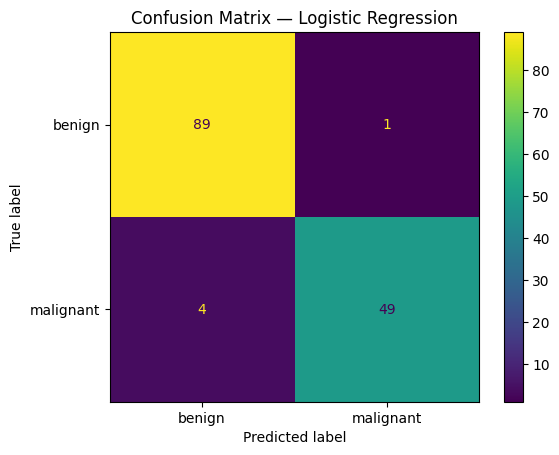

Confusion matrix:
[[89  1]
 [ 4 49]]


In [ ]:
# ============================================================
# D.1 Confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[class_names[0], class_names[1]]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.grid(False)
plt.show()

print("Confusion matrix:")
print(cm)

## D.2 Accuracy, Precision, Recall, dan F1-Score

Beberapa metrik penting:

$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

$ \text{Precision} = \frac{TP}{TP + FP} $

$ \text{Recall} = \frac{TP}{TP + FN} $

$ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}} {\text{Precision} + \text{Recall}} $

Interpretasi ringkas:

- **Accuracy**: proporsi prediksi yang benar.
- **Precision**: dari yang diprediksi positif, berapa yang benar-benar positif.
- **Recall**: dari yang benar-benar positif, berapa yang berhasil ditemukan model.
- **F1-score**: kompromi antara precision dan recall.

In [ ]:
# ============================================================
# D.2 Evaluasi model logistic regression
# ============================================================

evaluasi_klasifikasi(
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    nama_model="Logistic Regression"
)

=== Evaluasi Logistic Regression ===
Accuracy : 0.965
Precision: 0.98
Recall   : 0.9245
F1-score : 0.9515
ROC-AUC  : 0.9962

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## D.3 Baseline Model

Model yang baik harus dibandingkan dengan baseline.

Baseline sederhana adalah model yang selalu memprediksi kelas mayoritas.

Jika model kita tidak lebih baik dari baseline, maka model tersebut belum berguna.

In [ ]:
# ============================================================
# D.3 Membuat baseline model
# ============================================================

baseline_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

evaluasi_klasifikasi(
    y_true=y_test,
    y_pred=y_pred_baseline,
    nama_model="Baseline: Most Frequent Class"
)

=== Evaluasi Baseline: Most Frequent Class ===
Accuracy : 0.6294
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        90
           1       0.00      0.00      0.00        53

    accuracy                           0.63       143
   macro avg       0.31      0.50      0.39       143
weighted avg       0.40      0.63      0.49       143



## D.4 ROC Curve dan ROC-AUC

ROC curve menggambarkan hubungan antara:

- **True Positive Rate (TPR)**, dan
- **False Positive Rate (FPR)**

pada berbagai threshold.

ROC-AUC mengukur kemampuan model membedakan dua kelas.

Nilai ROC-AUC:

| Nilai | Interpretasi |
|---|---|
| 0.5 | mendekati tebakan acak |
| 0.7–0.8 | cukup |
| 0.8–0.9 | baik |
| > 0.9 | sangat baik |

Interpretasi ini bersifat umum dan tetap harus disesuaikan dengan konteks masalah.

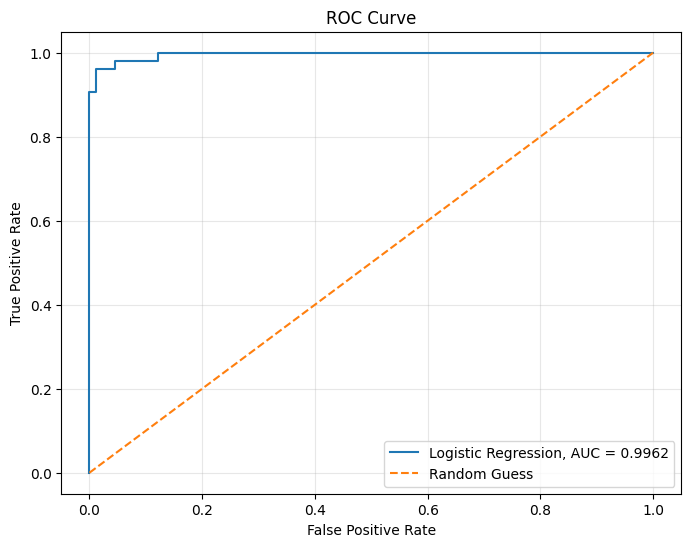

In [ ]:
# ============================================================
# D.4 ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression, AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## D.5 Pengaruh Threshold

Default threshold biasanya 0.5.  
Namun, threshold dapat diubah sesuai konsekuensi kesalahan.

Contoh:

- Dalam diagnosis penyakit, **false negative** bisa berbahaya.
- Dalam deteksi spam, **false positive** bisa mengganggu karena email penting bisa masuk spam.

Oleh karena itu, pemilihan threshold perlu mempertimbangkan konteks keputusan.

In [ ]:
# ============================================================
# D.5 Membandingkan beberapa threshold
# ============================================================

threshold_list = [0.3, 0.5, 0.7]

for threshold in threshold_list:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(f"Threshold = {threshold}")
    print("=" * 60)
    print("Accuracy :", round(accuracy_score(y_test, y_pred_threshold), 4))
    print("Precision:", round(precision_score(y_test, y_pred_threshold, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_test, y_pred_threshold), 4))
    print("F1-score :", round(f1_score(y_test, y_pred_threshold), 4))


Threshold = 0.3
Accuracy : 0.979
Precision: 0.9808
Recall   : 0.9623
F1-score : 0.9714

Threshold = 0.5
Accuracy : 0.965
Precision: 0.98
Recall   : 0.9245
F1-score : 0.9515

Threshold = 0.7
Accuracy : 0.965
Precision: 1.0
Recall   : 0.9057
F1-score : 0.9505


## D.6 Cross-Validation

Train-test split hanya membagi data satu kali.  
Untuk evaluasi yang lebih stabil, kita dapat menggunakan **cross-validation**.

Dalam $K$-fold cross-validation:

1. data dibagi menjadi $K$ bagian;
2. model dilatih pada $K-1$ bagian;
3. model diuji pada 1 bagian sisanya;
4. proses diulang sampai setiap bagian pernah menjadi data uji.

In [ ]:
# ============================================================
# D.6 Cross-validation
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_accuracy = cross_val_score(
    logreg_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

cv_auc = cross_val_score(
    logreg_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Accuracy tiap fold:", np.round(cv_accuracy, 4))
print("Rata-rata accuracy:", round(cv_accuracy.mean(), 4))
print("Standar deviasi accuracy:", round(cv_accuracy.std(), 4))

print("\nROC-AUC tiap fold:", np.round(cv_auc, 4))
print("Rata-rata ROC-AUC:", round(cv_auc.mean(), 4))
print("Standar deviasi ROC-AUC:", round(cv_auc.std(), 4))

Accuracy tiap fold: [0.9737 0.9474 0.9649 0.9912 0.9912]
Rata-rata accuracy: 0.9737
Standar deviasi accuracy: 0.0166

ROC-AUC tiap fold: [0.9951 0.9977 0.9851 1.     0.9987]
Rata-rata ROC-AUC: 0.9953
Standar deviasi ROC-AUC: 0.0053


## Check Point 3

Jawab secara singkat:

1. Apa informasi utama dari confusion matrix?
2. Apa perbedaan precision dan recall?
3. Kapan recall lebih penting daripada precision?
4. Mengapa baseline model diperlukan?
5. Mengapa cross-validation lebih stabil daripada single train-test split?

# Bagian E — K-Means Clustering

Pada bagian ini kita mempelajari **k-means clustering**.

K-means bertujuan membagi data menjadi $K$ cluster sedemikian sehingga observasi dalam cluster yang sama relatif mirip.

Secara intuitif, algoritma k-means bekerja sebagai berikut:

1. tentukan jumlah cluster $K$;
2. pilih pusat cluster awal;
3. tempatkan setiap observasi ke pusat cluster terdekat;
4. perbarui pusat cluster;
5. ulangi sampai cluster stabil.

K-means meminimalkan variasi dalam cluster atau **within-cluster sum of squares**.

## E.1 Dataset Simulasi untuk Memahami K-Means

Kita mulai dengan dataset simulasi agar struktur cluster mudah dilihat.

In [ ]:
# ============================================================
# E.1 Membuat data simulasi cluster
# ============================================================

X_blob, y_blob_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=4,
    random_state=RANDOM_STATE
)

blob_df = pd.DataFrame(X_blob, columns=["x1", "x2"])
blob_df.head()

,x1,x2
0,-10.6758,3.9241
1,-12.2800,5.7853
2,0.7810,4.1309
3,-7.7504,-2.4850
4,-16.9908,3.2912


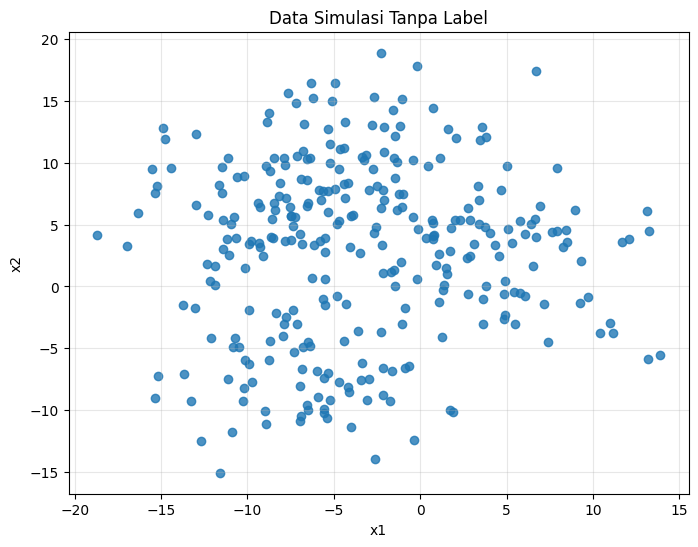

In [ ]:
# ============================================================
# E.2 Visualisasi data simulasi tanpa label
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(blob_df["x1"], blob_df["x2"], alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data Simulasi Tanpa Label")
plt.grid(True, alpha=0.3)
plt.show()

## E.2 Menerapkan K-Means

Misalkan kita memilih $K=4$ karena dari visualisasi tampak ada empat kelompok.

Dalam praktik nyata, jumlah cluster biasanya belum diketahui.  
Nanti kita pelajari cara memilihnya menggunakan elbow method dan silhouette score.

In [ ]:
# ============================================================
# E.3 K-means dengan K = 4
# ============================================================

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_label = kmeans_4.fit_predict(blob_df)

blob_df["cluster"] = cluster_label

print("Label cluster unik:", np.unique(cluster_label))
print("Inertia:", round(kmeans_4.inertia_, 4))

blob_df.head()

Label cluster unik: [0 1 2 3]
Inertia: 7024.5836


,x1,x2,cluster
0,-10.6758,3.9241,0
1,-12.2800,5.7853,0
2,0.7810,4.1309,1
3,-7.7504,-2.4850,2
4,-16.9908,3.2912,0


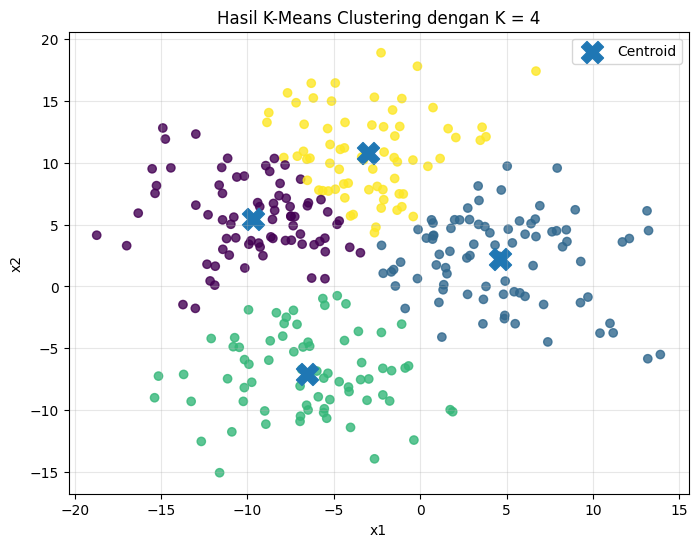

In [ ]:
# ============================================================
# E.4 Visualisasi hasil clustering
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    blob_df["x1"],
    blob_df["x2"],
    c=blob_df["cluster"],
    alpha=0.8
)

plt.scatter(
    kmeans_4.cluster_centers_[:, 0],
    kmeans_4.cluster_centers_[:, 1],
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Hasil K-Means Clustering dengan K = 4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## E.3 Elbow Method

**Elbow method** menggunakan nilai inertia.

Inertia adalah jumlah jarak kuadrat antara observasi dan centroid cluster-nya.

Semakin besar $K$, inertia biasanya semakin kecil.  
Namun, kita mencari titik di mana penurunan inertia mulai melambat.

Titik tersebut disebut "elbow".

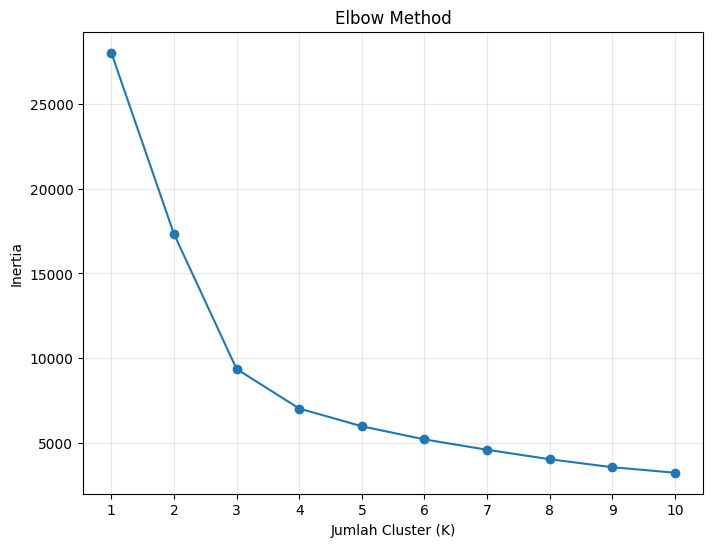

,K,Inertia
0,1,28036.1663
1,2,17333.5945
2,3,9359.1470
3,4,7024.5836
4,5,5976.0514
5,6,5199.4910
6,7,4587.9265
7,8,4029.6780
8,9,3557.7767
9,10,3232.6319


In [ ]:
# ============================================================
# E.5 Elbow method
# ============================================================

k_values = range(1, 11)
inertia_values = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(blob_df[["x1", "x2"]])
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(list(k_values), inertia_values, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values
})

## E.4 Silhouette Score

Silhouette score mengukur seberapa baik suatu observasi cocok dengan cluster-nya dibandingkan dengan cluster lain.

Nilai silhouette berada pada rentang:

$ -1 \leq s \leq 1.$

Interpretasi umum:

| Nilai | Interpretasi |
|---|---|
| mendekati 1 | cluster baik dan terpisah |
| sekitar 0 | observasi berada di batas antarcluster |
| negatif | kemungkinan observasi masuk cluster yang kurang tepat |

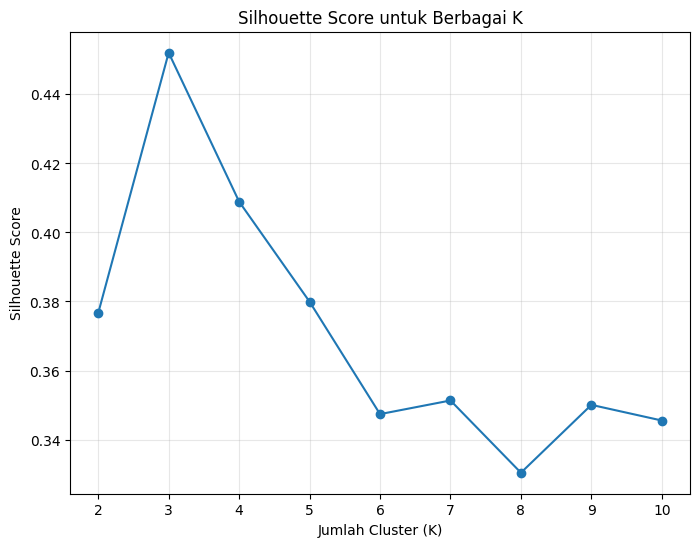

,K,Silhouette_Score
0,2,0.3766
1,3,0.4521
2,4,0.4089
3,5,0.3799
4,6,0.3474
5,7,0.3513
6,8,0.3304
7,9,0.3501
8,10,0.3455


In [ ]:
# ============================================================
# E.6 Silhouette score untuk beberapa nilai K
# ============================================================

silhouette_values = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(blob_df[["x1", "x2"]])
    score = silhouette_score(blob_df[["x1", "x2"]], labels)
    silhouette_values.append(score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_values, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai K")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "K": list(range(2, 11)),
    "Silhouette_Score": silhouette_values
})

## Check Point 4

Jawab secara singkat:

1. Mengapa k-means membutuhkan jumlah cluster $K$?
2. Apa arti centroid dalam k-means?
3. Apa arti inertia?
4. Bagaimana elbow method digunakan?
5. Apa kelebihan silhouette score dibanding hanya melihat inertia?

# Bagian F — K-Means pada Dataset Iris

Sekarang kita menerapkan k-means pada dataset **Iris**.

Dataset Iris sebenarnya memiliki label spesies, tetapi untuk clustering kita akan mengabaikan label tersebut saat membangun model.

Tujuan:

1. mengelompokkan bunga iris berdasarkan fitur numerik;
2. melihat apakah cluster yang terbentuk mendekati spesies asli;
3. memahami bahwa clustering tidak selalu sama dengan klasifikasi.

In [ ]:
# ============================================================
# F.1 Load dataset Iris
# ============================================================

iris = load_iris()

X_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y_iris = pd.Series(
    iris.target,
    name="species_code"
)

iris_df = X_iris.copy()
iris_df["species_code"] = y_iris
iris_df["species_name"] = iris_df["species_code"].map(dict(enumerate(iris.target_names)))

print("Ukuran dataset Iris:", iris_df.shape)
iris_df.head()

Ukuran dataset Iris: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# ============================================================
# F.2 Distribusi spesies asli
# ============================================================

print("Distribusi spesies asli:")
print(iris_df["species_name"].value_counts())

print("\nRingkasan statistik fitur:")
X_iris.describe()

Distribusi spesies asli:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Ringkasan statistik fitur:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0573,3.7580,1.1993
std,0.8281,0.4359,1.7653,0.7622
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


## F.1 Standardisasi Data

K-means menggunakan jarak Euclidean.  
Karena itu, fitur dengan skala lebih besar dapat mendominasi hasil clustering.

Meskipun fitur Iris memiliki skala yang relatif dekat, standardisasi tetap dilakukan agar praktiknya konsisten.

In [ ]:
# ============================================================
# F.3 Standardisasi fitur Iris
# ============================================================

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

X_iris_scaled_df = pd.DataFrame(
    X_iris_scaled,
    columns=iris.feature_names
)

X_iris_scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.9007,1.0190,-1.3402,-1.3154
1,-1.1430,-0.1320,-1.3402,-1.3154
2,-1.3854,0.3284,-1.3971,-1.3154
3,-1.5065,0.0982,-1.2834,-1.3154
4,-1.0218,1.2492,-1.3402,-1.3154


## F.2 Memilih Jumlah Cluster

Karena dataset Iris memiliki tiga spesies, kita dapat mencoba $K=3$.  
Namun, dalam clustering nyata kita tidak boleh langsung mengandalkan label asli.

Kita tetap melihat elbow method dan silhouette score.

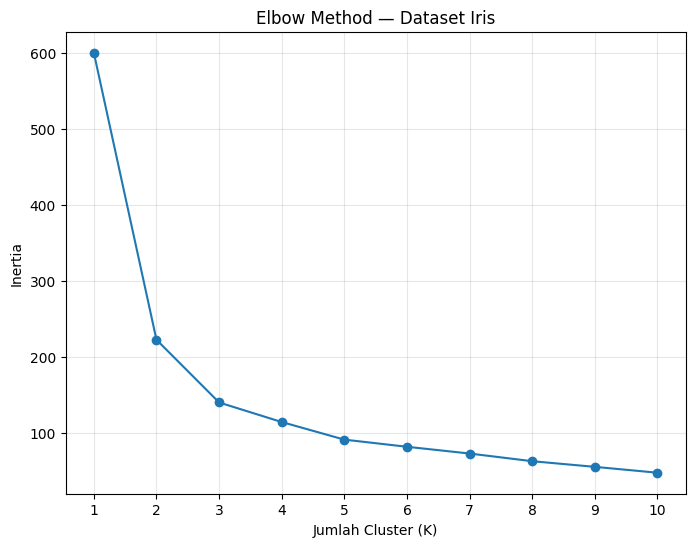

In [ ]:
# ============================================================
# F.4 Elbow method pada dataset Iris
# ============================================================

k_values = range(1, 11)
iris_inertia = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_iris_scaled)
    iris_inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(list(k_values), iris_inertia, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Dataset Iris")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

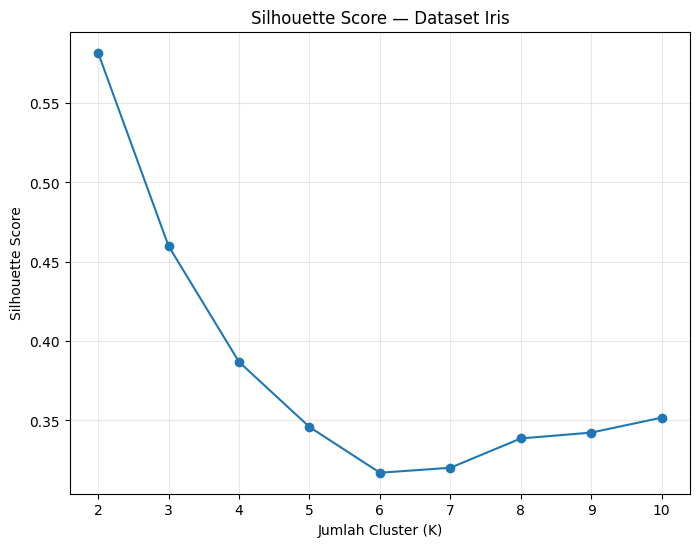

,K,Silhouette_Score
0,2,0.5818
1,3,0.4599
2,4,0.3869
3,5,0.3459
4,6,0.3171
5,7,0.3202
6,8,0.3387
7,9,0.3424
8,10,0.3518


In [ ]:
# ============================================================
# F.5 Silhouette score pada dataset Iris
# ============================================================

iris_silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_iris_scaled)
    score = silhouette_score(X_iris_scaled, labels)
    iris_silhouette.append(score)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), iris_silhouette, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Dataset Iris")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "K": list(range(2, 11)),
    "Silhouette_Score": iris_silhouette
})

## F.3 K-Means dengan K = 3

Kita jalankan k-means dengan $K=3$, lalu bandingkan hasil cluster dengan spesies asli.

Perlu diingat:

> Nomor cluster tidak harus sama dengan nomor spesies.

Misalnya, cluster 0 tidak otomatis berarti `setosa`.

In [ ]:
# ============================================================
# F.6 K-means dengan K = 3 pada dataset Iris
# ============================================================

kmeans_iris = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

iris_cluster = kmeans_iris.fit_predict(X_iris_scaled)

iris_df["cluster"] = iris_cluster

print("Jumlah observasi per cluster:")
print(iris_df["cluster"].value_counts().sort_index())

iris_df.head()

Jumlah observasi per cluster:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species_name,cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


In [ ]:
# ============================================================
# F.7 Cross-tab antara cluster dan spesies asli
# ============================================================

pd.crosstab(
    iris_df["cluster"],
    iris_df["species_name"],
    rownames=["Cluster"],
    colnames=["Species"]
)

Species,setosa,versicolor,virginica
Cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


## F.4 Profil Cluster

Setelah mendapatkan cluster, langkah penting adalah interpretasi.

Kita dapat menghitung rata-rata fitur pada setiap cluster.

Tujuannya bukan hanya mendapatkan label cluster, tetapi memahami karakteristik setiap cluster.

In [ ]:
# ============================================================
# F.12 Profil cluster berdasarkan rata-rata fitur asli
# ============================================================

cluster_profile = iris_df.groupby("cluster")[iris.feature_names].mean()
cluster_profile

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.8019,2.6736,4.3698,1.4132
1,5.0060,3.4280,1.4620,0.2460
2,6.7809,3.0957,5.5106,1.9723


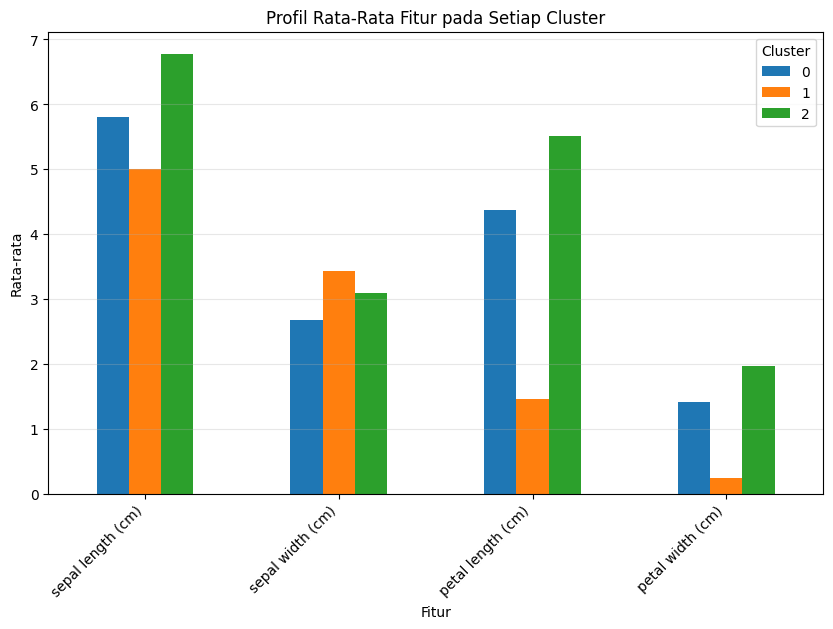

In [ ]:
# ============================================================
# F.13 Visualisasi profil cluster
# ============================================================

cluster_profile.T.plot(kind="bar", figsize=(10, 6))

plt.title("Profil Rata-Rata Fitur pada Setiap Cluster")
plt.xlabel("Fitur")
plt.ylabel("Rata-rata")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.legend(title="Cluster")
plt.show()

## Check Point 5

Jawab secara singkat:

1. Mengapa fitur perlu distandardisasi sebelum k-means?
2. Mengapa nomor cluster tidak langsung sama dengan nama kelas?
3. Apa kegunaan cross-tab antara cluster dan spesies asli?
4. Apa kegunaan PCA dalam visualisasi clustering?
5. Mengapa interpretasi profil cluster penting?

# Bagian G — Tugas

Kerjakan latihan berikut secara mandiri.

## Latihan 1 — Logistic Regression

Gunakan dataset Breast Cancer yang sama.

1. Pilih hanya 5 fitur berikut:
   - `mean radius`
   - `mean texture`
   - `mean perimeter`
   - `mean area`
   - `mean smoothness`

2. Bangun model logistic regression.
3. Evaluasi model dengan:
   - confusion matrix,
   - accuracy,
   - precision,
   - recall,
   - F1-score,
   - ROC-AUC.
4. Bandingkan hasilnya dengan model yang menggunakan semua fitur.
5. Jelaskan apakah model dengan 5 fitur masih cukup baik.

## Latihan 2 — Threshold

Gunakan model logistic regression dengan 5 fitur dari Latihan 1.

1. Bandingkan threshold 0.3, 0.5, dan 0.7.
2. Catat perubahan precision dan recall.
3. Jelaskan threshold mana yang lebih sesuai jika tujuan utama adalah mengurangi false negative.

## Latihan 3 — K-Means

Gunakan dataset Iris.

1. Jalankan k-means dengan $K=2$, $K=3$, dan $K=4$.
2. Hitung silhouette score untuk masing-masing $K$.
3. Bandingkan hasilnya.
4. Menurut Anda, jumlah cluster mana yang paling masuk akal?
5. Jelaskan alasan Anda.

## Latihan 4 — Interpretasi Cluster

Gunakan hasil k-means Iris dengan $K=3$.

1. Buat tabel rata-rata fitur untuk setiap cluster.
2. Tentukan cluster mana yang memiliki ukuran petal paling besar.
3. Tentukan cluster mana yang memiliki ukuran petal paling kecil.
4. Jelaskan kemungkinan karakteristik masing-masing cluster.